# MRKR Preprocessing Pipeline
**DICOM → 224×224 CLAHE PNG | Matches OAI & NHANES3 format**

Run every cell top to bottom in a fresh session.

| Cell | What it does |
|------|-------------|
| **0** | Mount Drive + install packages |
| **1** | Config, paths, shared helpers |
| **2** | Load plan, scan DICOMs with retry (handles Drive FUSE delay) |
| **3** | Preview 4 raw bilateral DICOMs |
| **4** | Define processing function + smoke test |
| **5** | Process all DICOMs → PNGs (resume-safe, ETA every 1000 files) |
| **6** | Build labels CSV + train/val/test split |
| **7** | Integrity check + spot-check |
| **8** | Sample grid: 5 crops per KL grade |

**Output format (matches OAI exactly):**
```
MRKR_{patient_id}_{side}_clahe-2.0_224px.png
mrkr_labels.csv  →  filename, subject_id, side, kl_grade, split, kl_source
```

## 0 — Mount Drive & Install Packages

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print('Drive mounted.')
except Exception:
    print('Not in Colab — skipping Drive mount.')


Mounted at /content/drive
Drive mounted.


In [3]:
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
                       'pydicom', 'opencv-python-headless',
                       'pylibjpeg', 'pylibjpeg-libjpeg'])

subprocess.check_call([sys.executable, '-m', 'pip',
                       'install', '--quiet', 'python-gdcm'])

subprocess.run(['apt-get', 'install', '-qq', '-y', 'rsync'], capture_output=True)

import pydicom
try:
    import gdcm
    print(f'gdcm {gdcm.Version.GetVersion()} ready — JPEG Lossless C decoder active.')
    print('Expected processing speed: 8-15 DICOM/s')
except ImportError as e:
    print(f'gdcm not available: {e}')
    print('Will use pylibjpeg fallback (~1-2 DICOM/s).')

print('All packages ready. RESTART RUNTIME NOW, then re-run Cell 0 and Cell 1.')


gdcm 3.2.6 ready — JPEG Lossless C decoder active.
Expected processing speed: 8-15 DICOM/s
All packages ready. RESTART RUNTIME NOW, then re-run Cell 0 and Cell 1.


## 1 — Config, Paths & Shared Helpers

In [4]:
import os, sys, time, random, threading, re, math
import concurrent.futures
import numpy as np
import pandas as pd
import pydicom
import pydicom.config as _pdcfg
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

DRIVE_BASE = Path('/content/drive/MyDrive/Master Thesis/MRKR')
DICOM_DIR  = DRIVE_BASE / 'dicoms'
META_DIR   = DRIVE_BASE / 'metadata'
LOG_DIR    = DRIVE_BASE / 'download_log'
PROC_DIR   = DRIVE_BASE / 'processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)

PLAN_CSV   = LOG_DIR  / 'download_plan.csv'
META_CSV   = META_DIR / 'MRKR_image_metadata.csv'
LABELS_OUT = DRIVE_BASE / 'mrkr_labels.csv'
DONE_LOG   = LOG_DIR / 'processed.txt'
ERROR_LOG  = LOG_DIR / 'process_errors.txt'

TARGET_SIZE  = 224
CLAHE_CLIP   = 2.0
CLAHE_TILE   = (8, 8)
SUFFIX       = f'_clahe-{CLAHE_CLIP}_224px'
MAX_WORKERS  = 8
LOG_FLUSH_N  = 50

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
SPLIT_SEED = 42

def parse_bool(v):
    if isinstance(v, bool): return v
    if v is None: return False
    if isinstance(v, (int, float)): return v != 0
    return str(v).strip().lower() in {'1','true','t','yes','y'}

def normalize_uint8(arr):
    lo = float(np.percentile(arr, 1))
    hi = float(np.percentile(arr, 99))
    if hi - lo < 1: lo, hi = float(arr.min()), float(arr.max())
    if hi <= lo: return np.zeros(arr.shape, dtype=np.uint8)
    return np.clip((arr-lo)/(hi-lo)*255, 0, 255).astype(np.uint8)

print('=== Path Status ===')
for name, p in [
    ('DICOMs ', DICOM_DIR), ('Metadata', META_CSV),
    ('Plan   ', PLAN_CSV),  ('Output  ', PROC_DIR),
]:
    print(f'  [{"OK" if p.exists() else "MISSING"}]  {name}: {p}')


=== Path Status ===
  [OK]  DICOMs : /content/drive/MyDrive/Master Thesis/MRKR/dicoms
  [OK]  Metadata: /content/drive/MyDrive/Master Thesis/MRKR/metadata/MRKR_image_metadata.csv
  [OK]  Plan   : /content/drive/MyDrive/Master Thesis/MRKR/download_log/download_plan.csv
  [OK]  Output  : /content/drive/MyDrive/Master Thesis/MRKR/processed


---
## 2 — Load Plan & Scan DICOMs

Scans the DICOM directory with retry logic.
Google Drive FUSE can take 1–2 minutes to index a 607 GB folder after mounting.
If the first scan finds 0 files it waits 30 seconds and retries up to 3 times.

In [5]:

plan = pd.read_csv(str(PLAN_CSV))
print(f'Plan rows : {len(plan):,}')
print(f'Columns   : {list(plan.columns)}')
print()

paths       = plan['dicom_path'].astype(str)
pat_ids     = paths.str.split('/').str[0]
fnames      = paths.str.split('/').str[-1]
local_paths = [DICOM_DIR / pat / fname
               for pat, fname in zip(pat_ids, fnames)]
path_index  = dict(zip(paths, local_paths))

DOWNLOAD_LOG = LOG_DIR / 'downloaded.txt'
if DOWNLOAD_LOG.exists():
    with open(DOWNLOAD_LOG) as f:
        downloaded_keys = set(f.read().splitlines())
    downloaded_fnames = {k.split('/')[-1] for k in downloaded_keys}
    path_index_found  = {p: lp for p, lp in path_index.items()
                         if lp.name in downloaded_fnames}
    print(f'Download log entries : {len(downloaded_keys):,}')
    print(f'Matched to plan      : {len(path_index_found):,}')
    print(f'Missing from disk    : {len(path_index)-len(path_index_found):,}')
else:
    print('Download log not found — trusting plan (missing files skip gracefully).')
    path_index_found = path_index.copy()

print()

kl_r   = pd.to_numeric(plan['R_KLG_inference'], errors='coerce')
kl_l   = pd.to_numeric(plan['L_KLG_inference'], errors='coerce')
all_kl = pd.concat([kl_r, kl_l]).dropna().astype(int)
print('KL distribution (model-predicted grades):')
vc = all_kl.value_counts().sort_index()
for k, n in vc.items():
    bar = '#' * int(n / len(all_kl) * 30)
    print(f'  KL{k}: {n:>7,}  ({100*n/len(all_kl):.1f}%)  {bar}')


Plan rows : 81,104
Columns   : ['empi_anon', 'dicom_path', 'laterality', 'view_position', 'R_KLG_inference', 'L_KLG_inference', 'kl_max', 'inverted', 'horizontal_flip']

Download log entries : 81,104
Matched to plan      : 81,104
Missing from disk    : 0

KL distribution (model-predicted grades):
  KL0:  49,107  (30.3%)  #########
  KL1:  10,569  (6.5%)  #
  KL2:  58,101  (35.8%)  ##########
  KL3:  27,304  (16.8%)  #####
  KL4:  17,127  (10.6%)  ###


---
## 3 — Preview Raw DICOMs

Shows 4 bilateral DICOMs before any processing.
Red line = midline split. Verify the split makes anatomical sense.

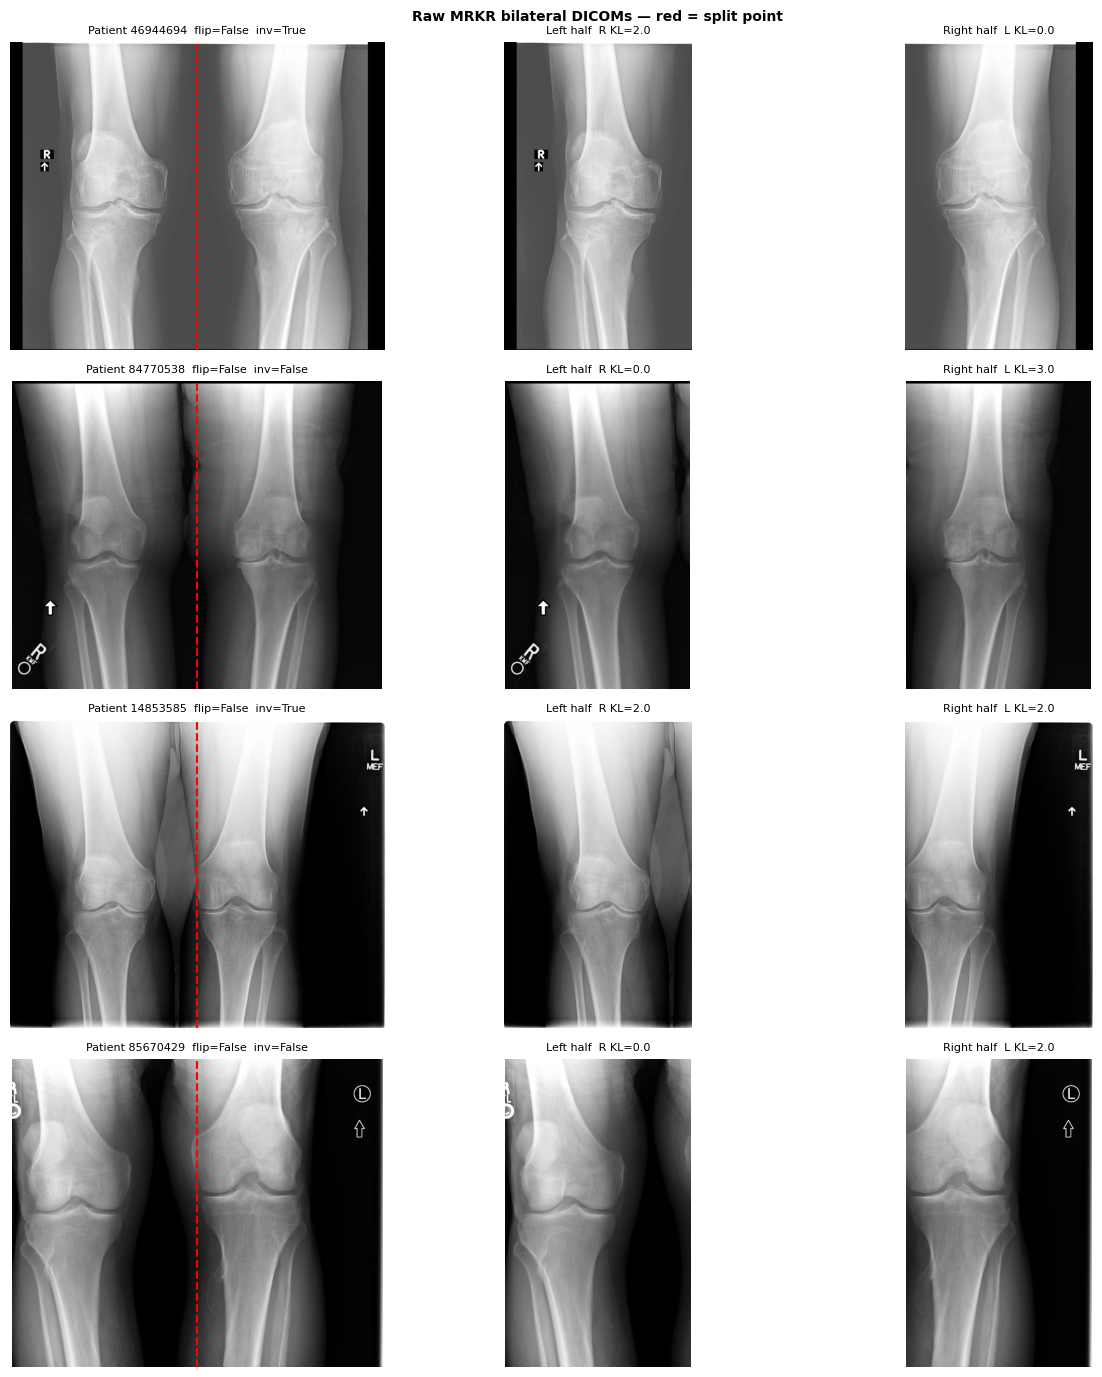

Preview saved.


In [6]:
def load_raw_uint8(dcm_path):
    try:
        ds  = pydicom.dcmread(str(dcm_path))
        arr = ds.pixel_array.astype(np.float32)
    except Exception:
        _pdcfg.settings.reading_validation_mode = 'WARN'
        ds  = pydicom.dcmread(str(dcm_path), force=True)
        arr = ds.pixel_array.astype(np.float32)
    arr = (arr * float(getattr(ds,'RescaleSlope',1))
               + float(getattr(ds,'RescaleIntercept',0)))
    photo = str(getattr(ds,'PhotometricInterpretation','MONOCHROME2')).upper()
    if photo == 'MONOCHROME1': arr = arr.max() - arr
    return normalize_uint8(arr), ds

if not path_index_found:
    print('No DICOMs found — re-run Cell 3.')
else:
    valid_keys  = list(path_index_found.keys())
    sample_keys = random.sample(valid_keys, min(4, len(valid_keys)))
    sample_rows = [plan[plan['dicom_path'].astype(str)==k].iloc[0]
                   for k in sample_keys]

    fig, axes = plt.subplots(len(sample_rows), 3,
                              figsize=(13, 3.5*len(sample_rows)))
    if len(sample_rows) == 1: axes = [axes]

    for ri, row in enumerate(sample_rows):
        raw_path = str(row['dicom_path'])
        arr, _   = load_raw_uint8(path_index_found[raw_path])
        mid = arr.shape[1] // 2
        flip = parse_bool(row.get('horizontal_flip', False))
        inv  = parse_bool(row.get('inverted', False))
        pat  = raw_path.split('/')[0]
        r_kl = row.get('R_KLG_inference','?')
        l_kl = row.get('L_KLG_inference','?')
        ll = ('L' if flip else 'R') + ' KL=' + str(l_kl if flip else r_kl)
        rl = ('R' if flip else 'L') + ' KL=' + str(r_kl if flip else l_kl)

        axes[ri][0].imshow(arr, cmap='gray', vmin=0, vmax=255)
        axes[ri][0].axvline(x=mid, color='red', lw=1.5, linestyle='--')
        axes[ri][0].set_title('Patient ' + pat + '  flip=' + str(flip) +
                               '  inv=' + str(inv), fontsize=8)
        axes[ri][0].axis('off')
        axes[ri][1].imshow(arr[:,:mid], cmap='gray', vmin=0, vmax=255)
        axes[ri][1].set_title('Left half  ' + ll, fontsize=8)
        axes[ri][1].axis('off')
        axes[ri][2].imshow(arr[:,mid:], cmap='gray', vmin=0, vmax=255)
        axes[ri][2].set_title('Right half  ' + rl, fontsize=8)
        axes[ri][2].axis('off')

    fig.suptitle('Raw MRKR bilateral DICOMs — red = split point',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(DRIVE_BASE/'preview_raw.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Preview saved.')


---
## 4 — Processing Function & Smoke Test

**Split logic:**
- `horizontal_flip=False` → image-left = patient's right knee
- `horizontal_flip=True`  → image-left = patient's left knee

Left crop is flipped horizontally to match right-knee orientation (OAI convention).

Smoke test:
  R: shape=(224, 224)  KL=0  min=9  max=255
  L: shape=(224, 224)  KL=0  min=3  max=255


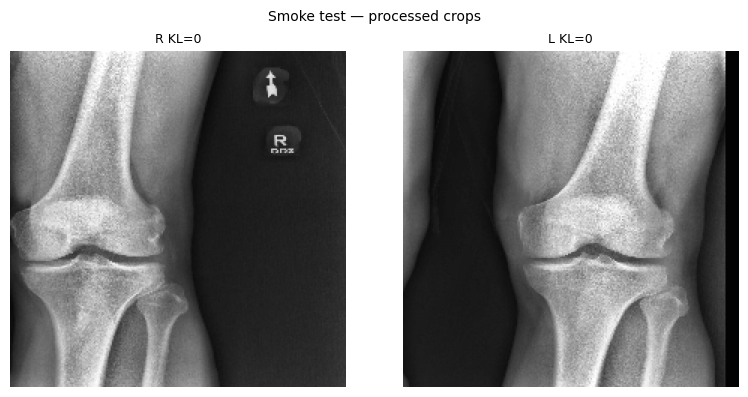

Smoke test passed.


In [7]:
_clahe_obj = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

def process_bilateral_dicom(local_path, row):
    try:
        ds = pydicom.dcmread(str(local_path))
        try:
            arr = ds.pixel_array.astype(np.float32)
        except Exception as e:
            return {'_error': 'decode:' + str(e)}
        arr  = (arr * float(getattr(ds,'RescaleSlope',1))
                    + float(getattr(ds,'RescaleIntercept',0)))
        photo = str(getattr(ds,'PhotometricInterpretation','MONOCHROME2')).upper()
        inv   = (photo=='MONOCHROME1') or parse_bool(row.get('inverted',False))
        arr   = normalize_uint8(arr)
        if inv: arr = 255 - arr
        mid = arr.shape[1] // 2
        if mid == 0: return {'_error': 'zero_width'}
        flip = parse_bool(row.get('horizontal_flip', False))
        r_raw = arr[:,:mid] if not flip else arr[:,mid:]
        l_raw = np.fliplr(arr[:,mid:] if not flip else arr[:,:mid])
        out = {}
        for side, crop, kl_col in [('R',r_raw,'R_KLG_inference'),
                                     ('L',l_raw,'L_KLG_inference')]:
            kl_raw = row.get(kl_col)
            if pd.isna(kl_raw): continue
            kl = int(float(kl_raw))
            if kl not in range(5): continue
            resized = cv2.resize(crop, (TARGET_SIZE, TARGET_SIZE),
                                 interpolation=cv2.INTER_LANCZOS4)
            out[side] = (_clahe_obj.apply(resized), kl)
        return out
    except Exception as e:
        return {'_error': str(e)}

if not path_index_found:
    print('Smoke test skipped — no DICOMs. Re-run Cell 3.')
else:
    first_key = next(iter(path_index_found))
    test_row  = plan[plan['dicom_path'].astype(str)==first_key].iloc[0]
    result    = process_bilateral_dicom(path_index_found[first_key], test_row)
    print('Smoke test:')
    for side, val in result.items():
        if side == '_error': print(f'  ERROR: {val}')
        else:
            a, kl = val
            print(f'  {side}: shape={a.shape}  KL={kl}  '
                  f'min={a.min()}  max={a.max()}')
    if not any(k=='_error' for k in result):
        fig, axes = plt.subplots(1, len(result), figsize=(4*len(result),4))
        if len(result)==1: axes=[axes]
        for ax,(side,(a,kl)) in zip(axes,result.items()):
            ax.imshow(a, cmap='gray', vmin=0, vmax=255)
            ax.set_title(side+' KL='+str(kl), fontsize=9)
            ax.axis('off')
        fig.suptitle('Smoke test — processed crops', fontsize=10)
        plt.tight_layout(); plt.show()
        print('Smoke test passed.')


---
## 5 — Process All DICOMs
Resume-safe — re-running skips already-processed files.
Plain-text heartbeat every 1,000 files so you always know progress.

In [8]:
import signal

if not path_index_found:
    raise RuntimeError('No DICOMs found. Re-run Cell 3.')

if DONE_LOG.exists():
    with open(DONE_LOG) as f:
        done_set = set(f.read().splitlines())
    print(f'Resume: {len(done_set):,} DICOMs already processed.')
else:
    done_set = set()

todo = [(raw,lp) for raw,lp in path_index_found.items()
        if raw not in done_set]

print(f'Remaining : {len(todo):,}')
print(f'Done      : {len(done_set):,}')
print(f'Total     : {len(path_index_found):,}')
print()

if not todo:
    print(f'All {len(done_set):,} DICOMs already processed.'
          if len(done_set) >= len(path_index_found)
          else 'Nothing to process.')
else:
    print('Building lookup index...', end=' ', flush=True)
    t0 = time.time()
    plan_lookup = plan.set_index('dicom_path').to_dict('index')
    print(f'done ({time.time()-t0:.1f}s)')

    try:
        import gdcm
        _executor_cls = concurrent.futures.ProcessPoolExecutor
        print(f'ProcessPoolExecutor x{MAX_WORKERS} — gdcm C decoder active')
        print('Expected speed: 8-15 DICOM/s')
    except ImportError:
        _executor_cls = concurrent.futures.ThreadPoolExecutor
        print(f'ThreadPoolExecutor x{MAX_WORKERS} — gdcm missing (~1-2 DICOM/s)')
        print('Install python-gdcm for full speed.')
    print()

    total        = len(todo)
    done_count   = ok_total = err_total = skip_total = 0
    pending_log  = []
    grand_start  = time.time()

    _interrupted = False
    def _sig(sig, frame):
        global _interrupted
        _interrupted = True
        print('\nInterrupt — flushing log and stopping.')
    signal.signal(signal.SIGTERM, _sig)
    try: signal.signal(signal.SIGINT, _sig)
    except Exception: pass

    def _worker(args):
        raw, drive_path, row_dict, proc_dir_s, suffix, sz, clip, tile = args
        import pydicom, cv2, numpy as np
        from PIL import Image
        from pathlib import Path

        _clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)

        def _norm(a):
            lo = float(np.percentile(a,1)); hi = float(np.percentile(a,99))
            if hi-lo < 1: lo,hi = float(a.min()),float(a.max())
            if hi <= lo: return np.zeros(a.shape, np.uint8)
            return np.clip((a-lo)/(hi-lo)*255,0,255).astype(np.uint8)

        def _pb(v):
            if isinstance(v,bool): return v
            if v is None: return False
            if isinstance(v,(int,float)): return v!=0
            return str(v).strip().lower() in {'1','true','t','yes','y'}

        try:
            ds = pydicom.dcmread(str(drive_path))
            try:
                arr = ds.pixel_array.astype(np.float32)
            except Exception as e:
                return raw, 'err', 'decode:' + str(e)

            arr   = (arr * float(getattr(ds,'RescaleSlope',1))
                         + float(getattr(ds,'RescaleIntercept',0)))
            photo = str(getattr(ds,'PhotometricInterpretation','MONOCHROME2')).upper()
            inv   = (photo=='MONOCHROME1') or _pb(row_dict.get('inverted',False))
            arr   = _norm(arr)
            if inv: arr = 255 - arr

            mid = arr.shape[1]//2
            if mid == 0: return raw,'err','zero_width'

            flip  = _pb(row_dict.get('horizontal_flip',False))
            r_raw = arr[:,:mid] if not flip else arr[:,mid:]
            l_raw = np.fliplr(arr[:,mid:] if not flip else arr[:,:mid])

            pat   = raw.split('/')[0]
            PROC  = Path(proc_dir_s)
            saved = 0
            for side, crop, kl_col in [('R',r_raw,'R_KLG_inference'),
                                         ('L',l_raw,'L_KLG_inference')]:
                kl_raw = row_dict.get(kl_col)
                if kl_raw is None or str(kl_raw) in ('nan','None',''): continue
                try: kl = int(float(kl_raw))
                except Exception: continue
                if kl not in range(5): continue
                out   = _clahe.apply(cv2.resize(crop,(sz,sz),
                                     interpolation=cv2.INTER_LANCZOS4))
                fname = 'MRKR_'+pat+'_'+side+suffix+'.png'
                Image.fromarray(out).save(str(PROC/fname))
                saved += 1

            return raw, ('ok' if saved>0 else 'skip'), ''
        except Exception as e:
            return raw, 'err', str(e)

    worker_args = [
        (raw, lp, dict(plan_lookup.get(raw) or {}),
         str(PROC_DIR), SUFFIX, TARGET_SIZE, CLAHE_CLIP, CLAHE_TILE)
        for raw, lp in todo
    ]

    overall_bar = tqdm(total=total, unit='DICOM', desc='Overall',
                       dynamic_ncols=True, position=0)
    proc_bar    = tqdm(total=total, unit='DICOM', desc='Processing',
                       dynamic_ncols=True, position=1, leave=False)

    with _executor_cls(max_workers=MAX_WORKERS) as ex:
        futs = {ex.submit(_worker, a): a[0] for a in worker_args}
        for fut in concurrent.futures.as_completed(futs):
            if _interrupted: break
            raw, status, msg = fut.result()

            if status == 'ok':
                ok_total += 1
                pending_log.append(raw)
            elif status == 'skip':
                skip_total += 1
                pending_log.append(raw)
            else:
                err_total += 1
                with open(ERROR_LOG,'a') as f:
                    f.write(raw + '\t' + msg + '\n')

            done_count += 1

            if len(pending_log) >= LOG_FLUSH_N:
                with open(DONE_LOG,'a') as f:
                    f.write('\n'.join(pending_log)+'\n')
                pending_log.clear()

            proc_bar.set_postfix(ok=ok_total, err=err_total, refresh=False)
            proc_bar.update(1)
            overall_bar.update(1)

            if done_count % 1000 == 0:
                elapsed = time.time()-grand_start
                rate    = ok_total/elapsed if elapsed>0 else 0
                eta_min = (total-done_count)/rate/60 if rate>0 else 0
                overall_bar.set_postfix(
                    ok=ok_total, err=err_total,
                    rate=f'{rate:.1f}/s', ETA=f'{eta_min:.0f}m')
                print(f'  [{100*done_count/total:.1f}%]  {done_count:,}/{total:,}  '
                      f'ok={ok_total:,}  err={err_total:,}  '
                      f'rate={rate:.1f} DICOM/s  ETA={eta_min:.0f}min',
                      flush=True)

    if pending_log:
        with open(DONE_LOG,'a') as f:
            f.write('\n'.join(pending_log)+'\n')

    overall_bar.close(); proc_bar.close()
    elapsed_h  = (time.time()-grand_start)/3600
    rate_final = ok_total/max(time.time()-grand_start,1)

    print()
    print('='*55)
    print(f'DONE in {elapsed_h:.2f}h  |  {rate_final:.1f} DICOM/s avg')
    print(f'Processed : {ok_total:,}  (~{ok_total*2:,} PNG crops)')
    print(f'Skipped   : {skip_total:,}')
    print(f'Errors    : {err_total:,}')
    if err_total: print(f'Error log : {ERROR_LOG}')
    print()

    print('=== Duplicate Audit ===')
    from collections import Counter
    all_pngs  = list(PROC_DIR.glob('MRKR_*_clahe*.png'))
    true_dups = {k:v for k,v in Counter(p.stem for p in all_pngs).items() if v>1}
    if true_dups:
        print(f'  TRUE DUPLICATES: {len(true_dups)}')
        for s,c in list(true_dups.items())[:5]: print(f'    {s}: {c}x')
    else:
        print(f'  No duplicates in {len(all_pngs):,} PNGs.')
    done_total = sum(1 for _ in open(DONE_LOG)) if DONE_LOG.exists() else 0
    print(f'  Done-log : {done_total:,}  |  PNGs : {len(all_pngs):,}')
    print('='*55)


Resume: 64,109 DICOMs already processed.
Remaining : 16,995
Done      : 64,109
Total     : 81,104

Building lookup index... done (0.3s)
ProcessPoolExecutor x8 — gdcm C decoder active
Expected speed: 8-15 DICOM/s



Overall:   0%|          | 0/16995 [00:00<?, ?DICOM/s]

Processing:   0%|          | 0/16995 [00:00<?, ?DICOM/s]

  [5.9%]  1,000/16,995  ok=997  err=3  rate=1.9 DICOM/s  ETA=140min
  [11.8%]  2,000/16,995  ok=1,997  err=3  rate=2.1 DICOM/s  ETA=119min
  [17.7%]  3,000/16,995  ok=2,997  err=3  rate=2.1 DICOM/s  ETA=109min
  [23.5%]  4,000/16,995  ok=3,996  err=4  rate=2.2 DICOM/s  ETA=99min
  [29.4%]  5,000/16,995  ok=4,996  err=4  rate=2.2 DICOM/s  ETA=91min
  [35.3%]  6,000/16,995  ok=5,996  err=4  rate=2.2 DICOM/s  ETA=83min
  [41.2%]  7,000/16,995  ok=6,996  err=4  rate=2.2 DICOM/s  ETA=75min
  [47.1%]  8,000/16,995  ok=7,996  err=4  rate=2.2 DICOM/s  ETA=68min
  [53.0%]  9,000/16,995  ok=8,994  err=6  rate=2.2 DICOM/s  ETA=61min
  [58.8%]  10,000/16,995  ok=9,994  err=6  rate=2.2 DICOM/s  ETA=53min
  [64.7%]  11,000/16,995  ok=10,994  err=6  rate=2.2 DICOM/s  ETA=45min
  [70.6%]  12,000/16,995  ok=11,993  err=7  rate=2.2 DICOM/s  ETA=38min
  [76.5%]  13,000/16,995  ok=12,993  err=7  rate=2.2 DICOM/s  ETA=30min
  [82.4%]  14,000/16,995  ok=13,992  err=8  rate=2.2 DICOM/s  ETA=23min
  [88.3%]  

---
## 6 — Build Labels CSV & Split

Output: `mrkr_labels.csv` — same schema as `oai_processed_labels.csv`.
Stratified subject-level split (both knees always in same group).

In [9]:
import re

if not DRIVE_BASE.exists():
    raise RuntimeError('Drive not mounted. Run Cell 0.')
if not any(PROC_DIR.glob('MRKR_*_clahe*.png')):
    raise RuntimeError('No processed PNGs found. Run Cell 6 first.')

print('Building labels CSV ...')
pngs = list(PROC_DIR.glob('MRKR_*_clahe*.png'))
print(f'PNG files found: {len(pngs):,}')

fnames_s = pd.Series([p.name for p in pngs])
parsed   = fnames_s.str.extract(r'^MRKR_(\d+)_(R|L)_')
parsed.columns = ['subject_id','side']
parsed['filename'] = fnames_s.values
df = parsed.dropna(subset=['subject_id','side']).reset_index(drop=True)
print(f'Parsed : {len(df):,} rows')

kl_r = plan[['dicom_path','R_KLG_inference']].copy()
kl_r['subject_id'] = plan['dicom_path'].astype(str).str.split('/').str[0]
kl_r['side'] = 'R'
kl_r = kl_r.rename(columns={'R_KLG_inference':'kl_grade'})
kl_l = plan[['dicom_path','L_KLG_inference']].copy()
kl_l['subject_id'] = plan['dicom_path'].astype(str).str.split('/').str[0]
kl_l['side'] = 'L'
kl_l = kl_l.rename(columns={'L_KLG_inference':'kl_grade'})

kl_long = (pd.concat([kl_r[['subject_id','side','kl_grade']],
                       kl_l[['subject_id','side','kl_grade']]])
            .dropna(subset=['kl_grade'])
            .drop_duplicates(subset=['subject_id','side']))
kl_long['kl_grade'] = pd.to_numeric(kl_long['kl_grade'], errors='coerce').astype('Int64')
kl_long = kl_long[kl_long['kl_grade'].between(0,4)]

df = df.merge(kl_long, on=['subject_id','side'], how='inner')
df['kl_grade'] = df['kl_grade'].astype(int)
print(f'After KL join: {len(df):,} rows')

print()
print('KL distribution:')
vc = df['kl_grade'].value_counts().sort_index()
for k, n in vc.items():
    bar = '#' * int(n/len(df)*30)
    print(f'  KL{k}: {n:>7,}  ({100*n/len(df):.1f}%)  {bar}')

print()
print('Creating split ...')
rng     = np.random.default_rng(SPLIT_SEED)
subj_kl = df.groupby('subject_id')['kl_grade'].max().reset_index()
subj_kl.columns = ['subject_id','max_kl']

split_map = {}
for kl in range(5):
    stratum = subj_kl.loc[subj_kl['max_kl']==kl,'subject_id'].tolist()
    if not stratum: continue
    rng.shuffle(stratum)
    n    = len(stratum)
    n_tr = max(1, round(n*TRAIN_FRAC))
    rem  = n - n_tr
    n_va = max(1,round(n*VAL_FRAC)) if rem>=2 else (1 if rem==1 else 0)
    n_tr = min(n_tr, n-n_va)
    for s in stratum[:n_tr]:           split_map[s]='train'
    for s in stratum[n_tr:n_tr+n_va]:  split_map[s]='val'
    for s in stratum[n_tr+n_va:]:      split_map[s]='test'

df['split']     = df['subject_id'].map(split_map).fillna('train')
df['kl_source'] = 'model_predicted'

print()
for sp in ['train','val','test']:
    print(f'  {sp:5s}: {int((df["split"]==sp).sum()):>7,}')

if LABELS_OUT.exists() and len(pd.read_csv(str(LABELS_OUT))) == 0:
    LABELS_OUT.unlink()
    print('\nDeleted previous empty labels file.')

df[['filename','subject_id','side','kl_grade','split','kl_source']].to_csv(
    str(LABELS_OUT), index=False)
print(f'\nLabels saved : {LABELS_OUT}')
print(f'Total rows   : {len(df):,}')


Building labels CSV ...
PNG files found: 93,053
Parsed : 93,053 rows
After KL join: 93,053 rows

KL distribution:
  KL0:  31,804  (34.2%)  ##########
  KL1:   6,224  (6.7%)  ##
  KL2:  32,320  (34.7%)  ##########
  KL3:  14,053  (15.1%)  ####
  KL4:   8,652  (9.3%)  ##

Creating split ...

  train:  65,131
  val  :  13,962
  test :  13,960

Labels saved : /content/drive/MyDrive/Master Thesis/MRKR/mrkr_labels.csv
Total rows   : 93,053


---
## 7 — Integrity Check & Spot-Check

In [ ]:
print('=== Integrity Check ===')
labels = pd.read_csv(str(LABELS_OUT))

done_total = sum(1 for _ in open(DONE_LOG)) if DONE_LOG.exists() else 0
exp_min    = done_total
exp_max    = done_total * 2
count_ok   = exp_min <= len(labels) <= exp_max

wrong_kl  = labels[~labels['kl_grade'].isin([0,1,2,3,4])]
bad_side  = labels[~labels['side'].isin(['R','L'])]
leaked    = labels.groupby('subject_id')['split'].nunique()
leakage   = int((leaked>1).sum())
miss_src  = int(labels['kl_source'].isna().sum()) if 'kl_source' in labels.columns else 0

print(f'  Total label rows   : {len(labels):,}')
print(f'  DICOMs in done-log : {done_total:,}')
print(f'  Expected PNG range : {exp_min:,} – {exp_max:,}')
print(f'  Count match        : {"OK" if count_ok else "CHECK — mismatch"}')
print(f'  Invalid KL grade   : {len(wrong_kl):,}')
print(f'  Invalid side       : {len(bad_side):,}')
print(f'  Subject leakage    : {leakage:,}  (must be 0)')
print(f'  Missing kl_source  : {miss_src:,}')

issues = len(wrong_kl)+len(bad_side)+leakage+(0 if count_ok else 1)
print()
print('  ALL CHECKS PASSED' if issues==0 else f'  {issues} issue(s) found')

print()
print('Spot-checking 20 random PNGs ...')
png_list = list(PROC_DIR.glob('MRKR_*_clahe*.png'))
if not png_list:
    print('  No PNG files found.')
else:
    bad_files = []
    for p in random.sample(png_list, min(20,len(png_list))):
        try:
            img = Image.open(str(p))
            arr = np.array(img)
            assert img.size==(224,224), f'size {img.size}'
            assert img.mode=='L',       f'mode {img.mode}'
            assert arr.max()>arr.min(), 'blank'
        except Exception as e:
            bad_files.append((p.name,str(e)))
    if bad_files:
        for name,err in bad_files: print(f'  FAIL {name}: {err}')
    else:
        print(f'  All {min(20,len(png_list))} spot-checks OK')


---
## 8 — Sample Grid

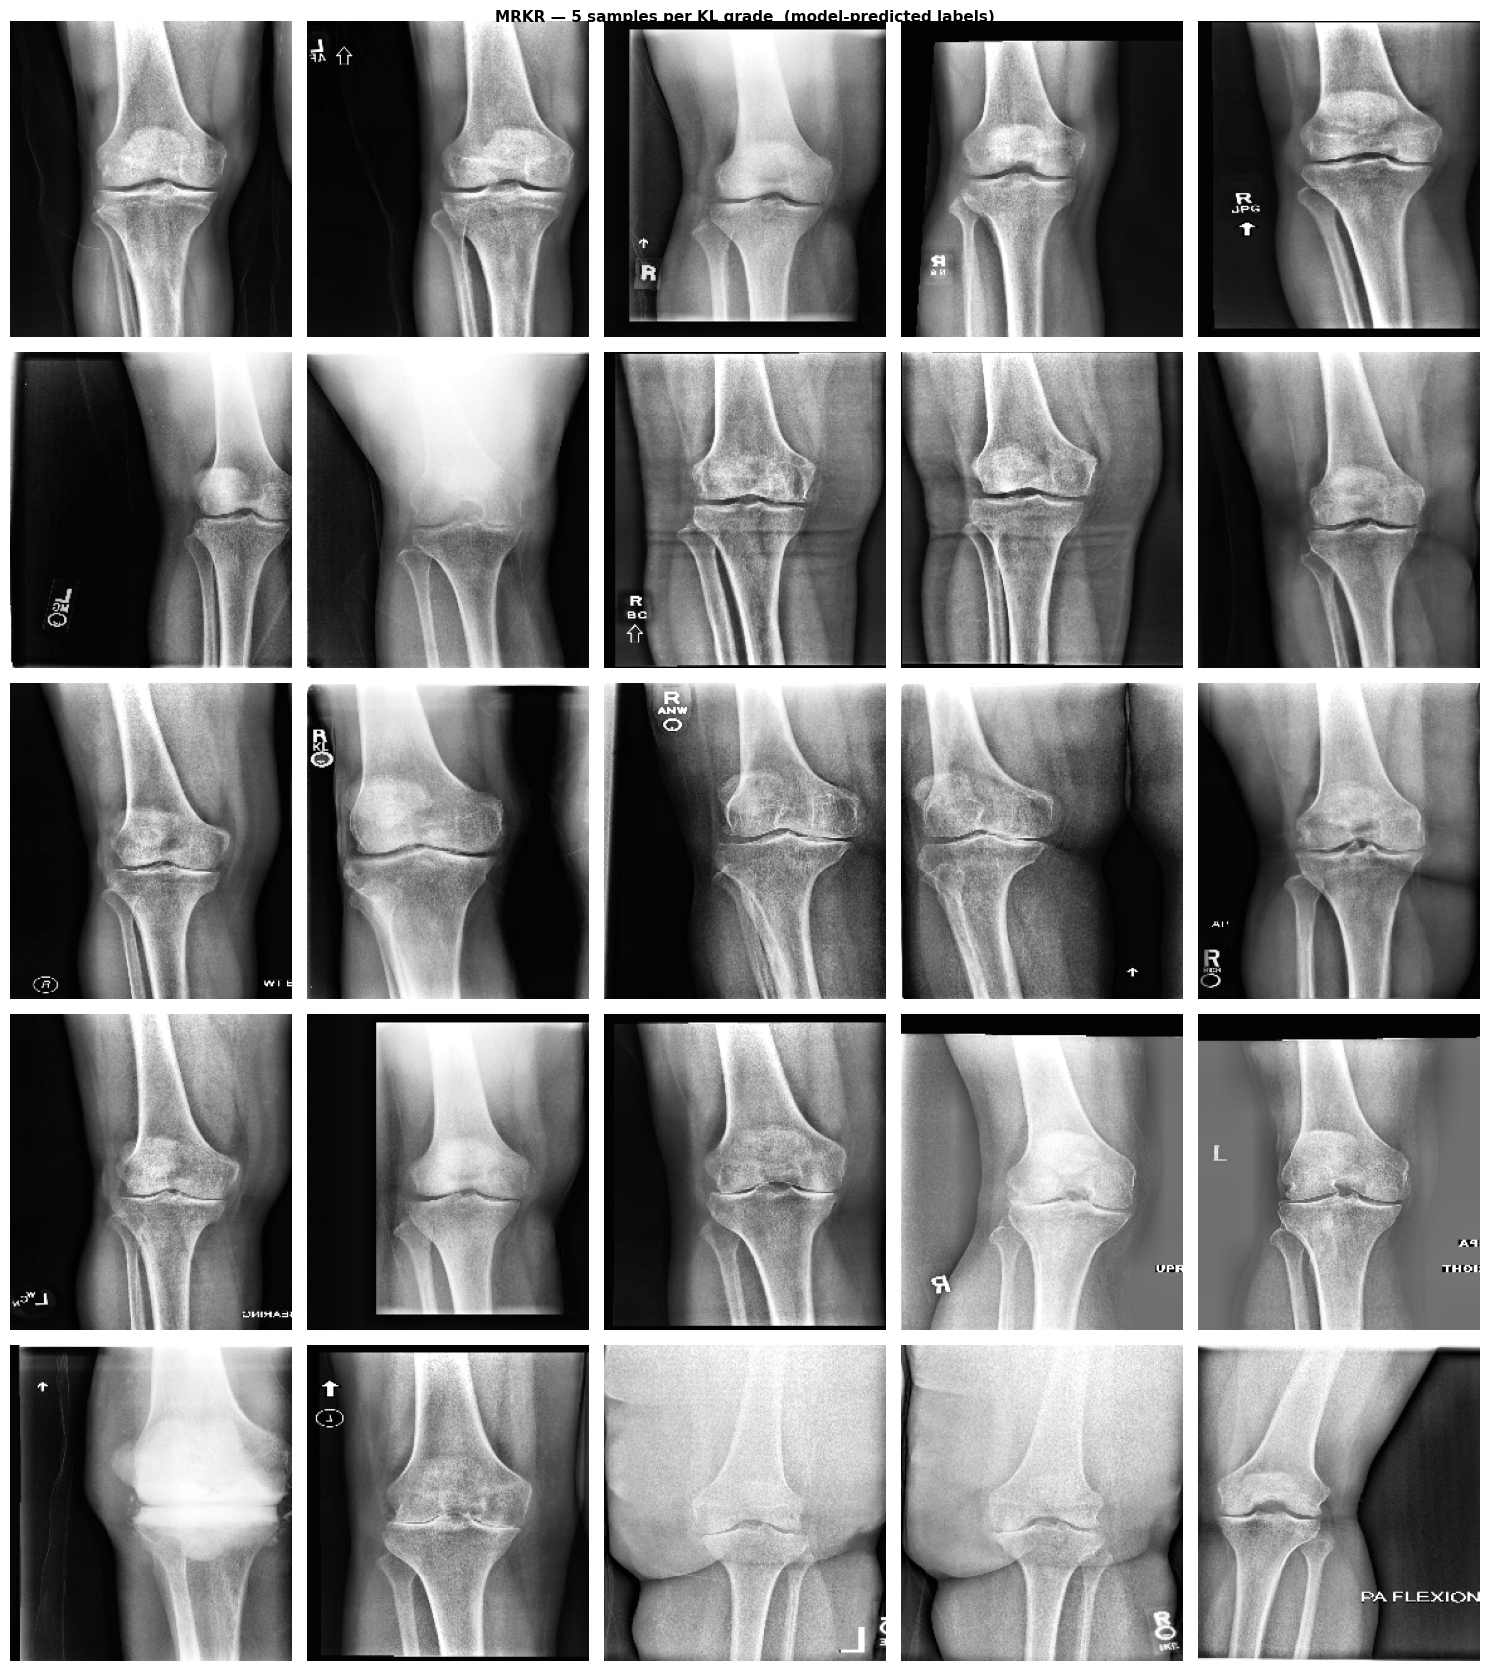

Sample grid saved.


In [11]:
KL_NAMES = ['Normal','Doubtful','Mild','Moderate','Severe']
N_PER_KL = 5

proc_png_set = {p.name for p in PROC_DIR.glob('MRKR_*_clahe*.png')}

fig, axes = plt.subplots(5, N_PER_KL, figsize=(N_PER_KL*3, 17))
for kl in range(5):
    sub = labels[labels['kl_grade']==kl].reset_index(drop=True)
    for j in range(N_PER_KL):
        ax = axes[kl][j]
        if j < len(sub):
            fname = sub.iloc[j]['filename']
            if fname in proc_png_set:
                arr = np.array(Image.open(str(PROC_DIR/fname)))
                ax.imshow(arr, cmap='gray', vmin=0, vmax=255, aspect='auto')
            else:
                ax.text(.5,.5,'missing',ha='center',va='center',
                        fontsize=8,color='red',transform=ax.transAxes)
        else:
            ax.text(.5,.5,'n/a',ha='center',va='center',
                    fontsize=8,color='gray',transform=ax.transAxes)
        if j==0:
            ax.set_ylabel('KL'+str(kl)+'\n'+KL_NAMES[kl],
                          fontsize=9,rotation=0,ha='right',
                          va='center',labelpad=55)
        ax.axis('off')

fig.suptitle('MRKR — 5 samples per KL grade  (model-predicted labels)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(DRIVE_BASE/'sample_grid.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Sample grid saved.')


---
## 9 — What's Next

MRKR preprocessing complete. Your three training datasets are now in identical format:

| Dataset | PNGs | Labels CSV | KL source |
|---------|------|-----------|-----------|
| OAI | `oai/processed/` | `oai_processed_labels.csv` | Radiologist |
| NHANES III | `nhanes3/processed/` | `nhanes3/labels_split.csv` | Radiologist |
| **MRKR** | **`MRKR/processed/`** | **`MRKR/mrkr_labels.csv`** | **Model-predicted** |

**Next: `oai_train.ipynb`**

Loads all three label CSVs, builds a combined training pool with weighted sampling,
trains ResNet-50 baseline then EfficientNet-B4 with hierarchical head,
evaluates on Mendeley OA holdout.